In [3]:
import os
from dotenv import load_dotenv
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
load_dotenv()

API_KEY = os.getenv("YELP_API_KEY")

headers = {
    "Authorization": f"Bearer {API_KEY}"
}

In [5]:
url = "https://api.yelp.com/v3/businesses/search"

params = {
    "location": "Chicago",
    "categories": "restaurants",
    "limit": 50
}

response = requests.get(
    url,
    headers=headers,
    params=params
)

In [6]:
response.status_code

200

In [7]:
data = response.json()

data.keys()

dict_keys(['businesses', 'total', 'region'])

In [8]:
businesses = data["businesses"]

In [9]:
restaurants_df = pd.DataFrame(businesses)

In [10]:
restaurants_df.head()

,id,alias,name,image_url,is_closed,url,review_count,categories,rating,coordinates,transactions,price,location,phone,display_phone,distance,business_hours,attributes
0,cKZNbMvoqJaUe7n6lf6i7w,wildberry-pancakes-and-cafe-chicago-2,Wildberry Pancakes and Cafe,https://s3-media0.fl.yelpcdn.com/bphoto/sYdVm-...,False,https://www.yelp.com/biz/wildberry-pancakes-an...,10345,"[{'alias': 'pancakes', 'title': 'Pancakes'}, {...",4.4,"{'latitude': 41.884721645455315, 'longitude': ...","[pickup, delivery]",$$,"{'address1': '130 E Randolph St', 'address2': ...",+13129389777,(312) 938-9777,5083.943291,"[{'open': [{'is_overnight': False, 'start': '0...","{'business_temp_closed': None, 'menu_url': 'ht..."
1,qjnpkS8yZO8xcyEIy5OU9A,girl-and-the-goat-chicago,Girl & The Goat,https://s3-media0.fl.yelpcdn.com/bphoto/ya6gjD...,False,https://www.yelp.com/biz/girl-and-the-goat-chi...,10701,"[{'alias': 'newamerican', 'title': 'New Americ...",4.4,"{'latitude': 41.88419277030351, 'longitude': -...",[delivery],$$$,"{'address1': '809 W Randolph', 'address2': '',...",+13124926262,(312) 492-6262,3401.238676,"[{'open': [{'is_overnight': False, 'start': '1...","{'business_temp_closed': None, 'menu_url': 'ht..."
2,apyIymDFbUK7u-Y3V5kmkA,bavettes-bar-and-boeuf-chicago,Bavette's Bar & Boeuf,https://s3-media0.fl.yelpcdn.com/bphoto/mhw9kd...,False,https://www.yelp.com/biz/bavettes-bar-and-boeu...,3532,"[{'alias': 'steak', 'title': 'Steakhouses'}, {...",4.6,"{'latitude': 41.889295011779424, 'longitude': ...",[delivery],$$$$,"{'address1': '218 W Kinzie', 'address2': '', '...",+13126248154,(312) 624-8154,3965.692806,"[{'open': [{'is_overnight': False, 'start': '1...","{'business_temp_closed': None, 'menu_url': 'ht..."
3,DXwSYgiXqIVNdO9dazel6w,pequods-pizza-chicago-3,Pequod's Pizza,https://s3-media0.fl.yelpcdn.com/bphoto/8QJUNb...,False,https://www.yelp.com/biz/pequods-pizza-chicago...,8928,"[{'alias': 'pizza', 'title': 'Pizza'}]",3.9,"{'latitude': 41.92187, 'longitude': -87.664486}","[delivery, pickup]",$$,"{'address1': '2207 N Clybourn Ave', 'address2'...",+17733271512,(773) 327-1512,2147.863733,"[{'open': [{'is_overnight': True, 'start': '11...","{'business_temp_closed': None, 'menu_url': 'ht..."
4,1BHgaf25FpVSOXFpZF0pYw,trivoli-tavern-chicago,Trivoli Tavern,https://s3-media0.fl.yelpcdn.com/bphoto/kMNBfN...,False,https://www.yelp.com/biz/trivoli-tavern-chicag...,995,"[{'alias': 'tradamerican', 'title': 'American'}]",4.5,"{'latitude': 41.8837221888722, 'longitude': -8...",[delivery],$$,"{'address1': '114 N Green St', 'address2': Non...",+13123662646,(312) 366-2646,3373.213132,"[{'open': [{'is_overnight': False, 'start': '1...","{'business_temp_closed': None, 'menu_url': 'ht..."


In [11]:
restaurants_df.columns

Index(['id', 'alias', 'name', 'image_url', 'is_closed', 'url', 'review_count',
       'categories', 'rating', 'coordinates', 'transactions', 'price',
       'location', 'phone', 'display_phone', 'distance', 'business_hours',
       'attributes'],
      dtype='str')

In [12]:
restaurants_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              50 non-null     str    
 1   alias           50 non-null     str    
 2   name            50 non-null     str    
 3   image_url       50 non-null     str    
 4   is_closed       50 non-null     bool   
 5   url             50 non-null     str    
 6   review_count    50 non-null     int64  
 7   categories      50 non-null     object 
 8   rating          50 non-null     float64
 9   coordinates     50 non-null     object 
 10  transactions    50 non-null     object 
 11  price           46 non-null     str    
 12  location        50 non-null     object 
 13  phone           50 non-null     str    
 14  display_phone   50 non-null     str    
 15  distance        50 non-null     float64
 16  business_hours  50 non-null     object 
 17  attributes      50 non-null     object 
dtypes: 

In [13]:
restaurants_df.describe()

,review_count,rating,distance
count,50.000000,50.000000,50.000000
mean,1652.920000,4.378000,2950.027525
std,2491.744351,0.233247,2287.408119
min,105.000000,3.600000,196.305089
25%,474.000000,4.200000,1037.738444
50%,677.000000,4.400000,2725.553437
75%,1419.500000,4.500000,4143.033394
max,10701.000000,4.800000,10889.881295


In [14]:
restaurants_df.isnull().sum()

id                0
alias             0
name              0
image_url         0
is_closed         0
url               0
review_count      0
categories        0
rating            0
coordinates       0
transactions      0
price             4
location          0
phone             0
display_phone     0
distance          0
business_hours    0
attributes        0
dtype: int64

## Business Question 1

How are restaurant ratings distributed in Chicago?

Understanding the distribution of ratings allows us to evaluate the overall quality of restaurants available in the selected city. This information will later be compared with customer behavior and preferences to identify whether customers are surrounded by highly rated establishments.

In [15]:
restaurants_df["rating"].describe()

count    50.000000
mean      4.378000
std       0.233247
min       3.600000
25%       4.200000
50%       4.400000
75%       4.500000
max       4.800000
Name: rating, dtype: float64

In [16]:
restaurants_df["rating"].value_counts().sort_index()

rating
3.6     1
3.9     1
4.0     1
4.1     1
4.2    10
4.3     8
4.4    12
4.5     5
4.6     5
4.7     2
4.8     4
Name: count, dtype: int64

### Visualization

The following histogram illustrates the distribution of restaurant ratings in the selected sample. This visualization helps identify whether customer ratings are concentrated around specific values or spread across a wider range, providing a clearer understanding of the overall quality of restaurants in Chicago.

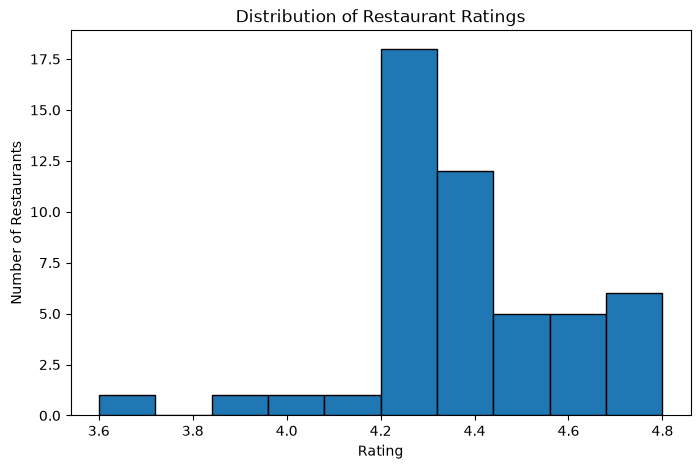

In [17]:
plt.figure(figsize=(8,5))

plt.hist(
    restaurants_df["rating"],
    bins=10,
    edgecolor="black"
)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")

plt.show()

### Insights

The distribution of restaurant price levels shows how the selected restaurants are positioned in terms of affordability. By identifying the most common price categories, we can better understand whether Chicago's restaurant market is primarily composed of low-cost, mid-range, or premium establishments. This provides valuable context for interpreting customer spending behavior in later stages of the project.

### Business Impact

Understanding the distribution of restaurant price levels is essential for comparing the local restaurant market with customer spending habits. In the next stage of the analysis, this information will be integrated with the customer dataset to evaluate whether customers tend to spend within the most common restaurant price ranges or if there are opportunities to recommend different market segments.

## Business Question 2

How are restaurants distributed across different price levels in Chicago?

Understanding the distribution of restaurant price levels allows us to characterize the affordability of the local restaurant market. This information will later be compared with customers' monthly restaurant spending to identify whether their spending habits align with the restaurant offerings available in Chicago.

In [18]:
restaurants_df["price"].value_counts(dropna=False)

price
$$      31
$$$     10
$$$$     4
NaN      4
$        1
Name: count, dtype: int64

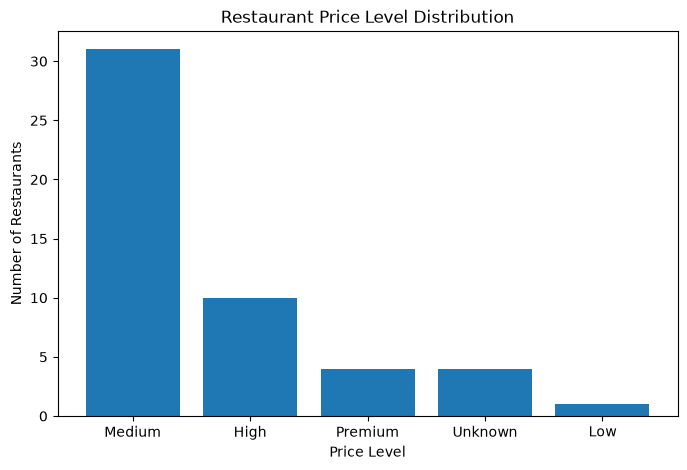

In [19]:
price_counts = (
    restaurants_df["price"]
    .fillna("Unknown")
    .replace({
        "$": "Low",
        "$$": "Medium",
        "$$$": "High",
        "$$$$": "Premium"
    })
    .value_counts()
)

plt.figure(figsize=(8,5))

plt.bar(
    price_counts.index,
    price_counts.values
)


plt.title("Restaurant Price Level Distribution")
plt.xlabel("Price Level")
plt.ylabel("Number of Restaurants")

plt.show()

### Insights

The price level distribution indicates that most restaurants in the selected sample belong to the **Medium** and **High** price categories. Only a small number of restaurants are classified as **Premium**, while a few businesses do not provide price information. Interestingly, no restaurants in the sample were classified in the **Low** price category.

### Business Impact

The predominance of medium- and high-priced restaurants suggests that customers in Chicago are primarily exposed to mid-range and premium dining options. This information will later be compared with customers' monthly restaurant spending and income levels to determine whether their spending behavior aligns with the pricing of restaurants available in the city.

In [20]:
for categoria in restaurants_df["categories"].iloc[0]:
    print(categoria["title"])


Pancakes
Waffles
Cafes


In [21]:
restaurants_df["category_titles"] = restaurants_df["categories"].apply(
    lambda categories: ", ".join(
        category["title"] for category in categories
    )
)

restaurants_df[
    ["name", "category_titles"]
].head()

,name,category_titles
0,Wildberry Pancakes and Cafe,"Pancakes, Waffles, Cafes"
1,Girl & The Goat,"New American, Bars, Bakeries"
2,Bavette's Bar & Boeuf,"Steakhouses, Seafood, Bars"
3,Pequod's Pizza,Pizza
4,Trivoli Tavern,American


In [22]:
restaurants_df["category_titles"].value_counts()

category_titles
Italian                                               2
Thai                                                  2
Pancakes, Waffles, Cafes                              1
New American, Bars, Bakeries                          1
Steakhouses, Seafood, Bars                            1
Pizza                                                 1
American                                              1
New American                                          1
Breweries, New American                               1
Peruvian                                              1
Pasta Shops, New American, Cocktail Bars              1
Wine Bars, Seafood, Steakhouses                       1
British, Pubs, Breakfast & Brunch                     1
Filipino, Bakeries, New American                      1
Vietnamese                                            1
New American, Modern European                         1
Asian Fusion, Bars                                    1
Mexican                         

In [25]:
category_df = restaurants_df.explode("category_list")

KeyError: 'category_list'